In [127]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from plotly import graph_objects as go
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [128]:
df= pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')
df.head()


,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [130]:
df.isna().sum()

EventName         0
DeviceIDHash      0
EventTimestamp    0
ExpId             0
dtype: int64

In [131]:
df.columns = [ 'event_name', 'user_id', 'timestamp', 'exp_id']
df["datetime"] = pd.to_datetime(df['timestamp'], unit="s")
df['date'] = df['datetime'].dt.date
df.head()

,event_name,user_id,timestamp,exp_id,datetime,date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


In [132]:
print('Total de eventos:', len(df))

Total de eventos: 244126


In [133]:
print('Total de usuários:', df['user_id'].nunique())

Total de usuários: 7551


In [134]:
eventos_por_usuario = df.groupby('user_id')['event_name'].count()
print('Média de eventos por usuário:', eventos_por_usuario.mean().round(2))

Média de eventos por usuário: 32.33


In [135]:
print('Data mínima:', df['datetime'].min())
print('Data máxima:', df['datetime'].max())

Data mínima: 2019-07-25 04:43:36
Data máxima: 2019-08-07 21:15:17


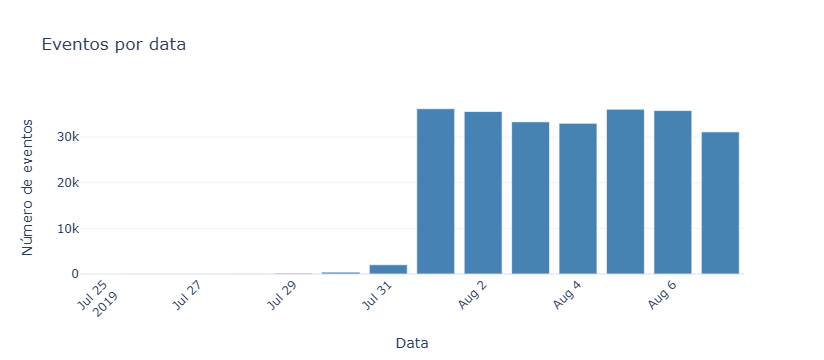

In [136]:
eventos_por_data = df.groupby('date')['event_name'].count().reset_index()
eventos_por_data.columns = ['date', 'count']

fig = go.Figure()

fig.add_trace(go.Bar(
    x=eventos_por_data['date'].astype(str),
    y=eventos_por_data['count'],
    marker_color='steelblue',
    hovertemplate='Data: %{x}<br>Eventos: %{y}<extra></extra>'
))

fig.update_layout(
    title='Eventos por data',
    xaxis_title='Data',
    yaxis_title='Número de eventos',
    xaxis_tickangle=-45,
    template='plotly_white'
)

fig.show()

## Análise do período dos dados

O histograma revela uma diferença clara no volume de eventos ao longo do tempo:

- **25 a 30 de julho:** volume praticamente zero — os dados estão incompletos nesse período
- **31 de julho:** volume muito baixo (cerca de 2 mil eventos) — ainda incompleto
- **1º de agosto em diante:** volume estável entre 30k e 35k eventos por dia — dados completos

### Conclusão
Os dados só se tornam confiáveis a partir de **1º de agosto de 2019**.
Os registros anteriores a essa data provavelmente aparecem nos logs por razões técnicas
e podem distorcer a análise. Por isso, vamos **filtrar e ignorar tudo antes de 01/08/2019**.

In [137]:
df = df[df['date'] >= pd.to_datetime('2019-08-01').date()]

print('Total de eventos após filtro:', len(df))
print('Total de usuários após filtro:', df['user_id'].nunique())

Total de eventos após filtro: 241298
Total de usuários após filtro: 7534


## Impacto da remoção dos dados incompletos

Após filtrar os registros anteriores a 01/08/2019:

| | Antes do filtro | Após o filtro | Perdido |
|---|---|---|---|
| **Eventos** | 244.126 | 241.298 | 2.828 |
| **Usuários** | 7.551 | 7.534 | 17 |

- Perdemos apenas **2.828 eventos** (1,2% do total) e **17 usuários** (0,2% do total)
- A perda é mínima e não compromete a análise
- O conjunto de dados filtrado representa fielmente o período de **01 a 07 de agosto de 2019**

In [138]:
print(df['exp_id'].value_counts())

248    84726
246    79425
247    77147
Name: exp_id, dtype: int64


## Verificação dos grupos experimentais

Os três grupos experimentais estão presentes nos dados filtrados:

| Grupo | Descrição | Eventos |
|---|---|---|
| **246** | Controle A | 79.425 |
| **247** | Controle B | 77.147 |
| **248** | Teste (nova fonte) | 84.726 |

- Todos os três grupos estão representados ✅
- Os grupos de controle (246 e 247) têm volumes similares entre si
- O grupo de teste (248) tem volume um pouco maior, o que é normal
- A análise estatística mais adiante confirmará se as diferenças são significativas

In [139]:
eventos = df.groupby('event_name')['user_id'].nunique().reset_index()
eventos.columns = ['event_name', 'users']
eventos['share'] = (eventos['users'] / df['user_id'].nunique() * 100).round(2)
eventos = eventos.sort_values('users', ascending=False).reset_index(drop=True)
print(eventos)

                event_name  users  share
0         MainScreenAppear   7419  98.47
1       OffersScreenAppear   4593  60.96
2         CartScreenAppear   3734  49.56
3  PaymentScreenSuccessful   3539  46.97
4                 Tutorial    840  11.15


## Funil de eventos

### Eventos ordenados por número de usuários

| Evento | Usuários | % do total |
|---|---|---|
| **MainScreenAppear** | 7.419 | 98,47% |
| **OffersScreenAppear** | 4.593 | 60,96% |
| **CartScreenAppear** | 3.734 | 49,56% |
| **PaymentScreenSuccessful** | 3.539 | 46,97% |
| **Tutorial** | 840 | 11,15% |

### Sequência lógica do funil
A sequência natural de compra é:
1. MainScreenAppear → tela inicial
2. OffersScreenAppear → tela de ofertas
3. CartScreenAppear → tela do carrinho
4. PaymentScreenSuccessful → pagamento concluído

O **Tutorial** não faz parte do funil principal pois é acessado
por apenas 11% dos usuários de forma independente.

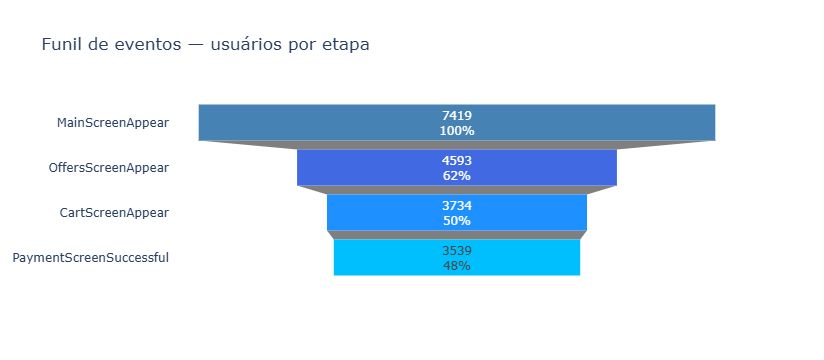

In [140]:
funil = eventos[eventos['event_name'] != 'Tutorial'].sort_values('users', ascending=False)

fig = go.Figure(go.Funnel(
    y=funil['event_name'],
    x=funil['users'],
    textinfo='value+percent initial',
    marker_color=['steelblue', 'royalblue', 'dodgerblue', 'deepskyblue']
))

fig.update_layout(
    title='Funil de eventos — usuários por etapa',
    template='plotly_white'
)

fig.show()

In [141]:
funil = funil.reset_index(drop=True)

for i in range(1, len(funil)):
    etapa_anterior = funil.loc[i-1, 'users']
    etapa_atual = funil.loc[i, 'users']
    perda = ((etapa_anterior - etapa_atual) / etapa_anterior * 100).round(2)
    print(f"{funil.loc[i-1, 'event_name']} → {funil.loc[i, 'event_name']}: perda de {perda}%")

total = (funil.loc[len(funil)-1, 'users'] / funil.loc[0, 'users'] * 100).round(2)
print(f"\nUsuários que completam o funil inteiro: {total}%")

MainScreenAppear → OffersScreenAppear: perda de 38.09%
OffersScreenAppear → CartScreenAppear: perda de 18.7%
CartScreenAppear → PaymentScreenSuccessful: perda de 5.22%

Usuários que completam o funil inteiro: 47.7%


## Análise do funil de eventos

### Perda de usuários entre etapas

| Etapa | Usuários | Perda para próxima etapa |
|---|---|---|
| MainScreenAppear | 7.419 | 38,09% ⚠️ |
| OffersScreenAppear | 4.593 | 18,70% |
| CartScreenAppear | 3.734 | 5,22% |
| PaymentScreenSuccessful | 3.539 | — |

### Conclusões

- **Maior perda:** entre a tela inicial e a tela de ofertas (**38,09%**)
  — quase 4 em cada 10 usuários abandonam o app logo na primeira etapa
- **Perda moderada:** entre ofertas e carrinho (**18,70%**)
- **Menor perda:** entre carrinho e pagamento (**5,22%**)
  — quem chega ao carrinho tem alta intenção de compra

### Taxa de conversão total
**47,7%** dos usuários que chegam à tela inicial completam o pagamento.

### Recomendação
O foco de melhoria deve ser na transição **MainScreenAppear → OffersScreenAppear**,
pois é onde o app perde mais usuários e onde pequenas melhorias teriam maior impacto.

In [142]:
usuarios_por_grupo = df.groupby('exp_id')['user_id'].nunique().reset_index()
usuarios_por_grupo.columns = ['grupo', 'usuarios']
print(usuarios_por_grupo)

   grupo  usuarios
0    246      2484
1    247      2513
2    248      2537


## Análise do experimento A/A/B

### Usuários por grupo experimental

| Grupo | Descrição | Usuários |
|---|---|---|
| **246** | Controle A | 2.484 |
| **247** | Controle B | 2.513 |
| **248** | Teste (nova fonte) | 2.537 |

- Os três grupos têm tamanhos muito similares ✅
- A divisão foi feita de forma equilibrada
- Grupos equilibrados são essenciais para que o teste seja válido

In [143]:

def teste_proporcao(evento, grupo1, grupo2, alpha=0.05):
    usuarios_g1 = df[df['exp_id'] == grupo1]['user_id'].nunique()
    usuarios_g2 = df[df['exp_id'] == grupo2]['user_id'].nunique()
    
    eventos_g1 = df[(df['exp_id'] == grupo1) & (df['event_name'] == evento)]['user_id'].nunique()
    eventos_g2 = df[(df['exp_id'] == grupo2) & (df['event_name'] == evento)]['user_id'].nunique()
    
    prop_g1 = eventos_g1 / usuarios_g1
    prop_g2 = eventos_g2 / usuarios_g2
    
    contagens = np.array([eventos_g1, eventos_g2])
    totais = np.array([usuarios_g1, usuarios_g2])
    
    stat, p_value = proportions_ztest(contagens, totais)
    
    resultado = 'DIFERENÇA SIGNIFICATIVA ⚠️' if p_value < alpha else 'Sem diferença significativa ✅'
    
    print(f"Evento: {evento}")
    print(f"  Grupo {grupo1}: {eventos_g1}/{usuarios_g1} = {prop_g1:.2%}")
    print(f"  Grupo {grupo2}: {eventos_g2}/{usuarios_g2} = {prop_g2:.2%}")
    print(f"  p-valor: {p_value:.4f} | alpha: {alpha} | {resultado}")
    print()

In [144]:
print("=== TESTE A/A: Grupos 246 vs 247 ===\n")
for evento in eventos['event_name'].tolist():
    teste_proporcao(evento, 246, 247)

=== TESTE A/A: Grupos 246 vs 247 ===

Evento: MainScreenAppear
  Grupo 246: 2450/2484 = 98.63%
  Grupo 247: 2476/2513 = 98.53%
  p-valor: 0.7571 | alpha: 0.05 | Sem diferença significativa ✅

Evento: OffersScreenAppear
  Grupo 246: 1542/2484 = 62.08%
  Grupo 247: 1520/2513 = 60.49%
  p-valor: 0.2481 | alpha: 0.05 | Sem diferença significativa ✅

Evento: CartScreenAppear
  Grupo 246: 1266/2484 = 50.97%
  Grupo 247: 1238/2513 = 49.26%
  p-valor: 0.2288 | alpha: 0.05 | Sem diferença significativa ✅

Evento: PaymentScreenSuccessful
  Grupo 246: 1200/2484 = 48.31%
  Grupo 247: 1158/2513 = 46.08%
  p-valor: 0.1146 | alpha: 0.05 | Sem diferença significativa ✅

Evento: Tutorial
  Grupo 246: 278/2484 = 11.19%
  Grupo 247: 283/2513 = 11.26%
  p-valor: 0.9377 | alpha: 0.05 | Sem diferença significativa ✅



## Teste A/A — Grupos de controle 246 vs 247

| Evento | Grupo 246 | Grupo 247 | p-valor | Resultado |
|---|---|---|---|---|
| MainScreenAppear | 98,63% | 98,53% | 0,7571 | Sem diferença ✅ |
| OffersScreenAppear | 62,08% | 60,49% | 0,2481 | Sem diferença ✅ |
| CartScreenAppear | 50,97% | 49,26% | 0,2288 | Sem diferença ✅ |
| PaymentScreenSuccessful | 48,31% | 46,08% | 0,1146 | Sem diferença ✅ |
| Tutorial | 11,19% | 11,26% | 0,9377 | Sem diferença ✅ |

### Conclusão
- Nenhum evento apresentou diferença estatisticamente significativa entre os dois grupos de controle
- Todos os p-valores estão bem acima do nível de significância (alpha = 0,05)
- Isso confirma que a divisão dos usuários foi feita corretamente ✅
- Os mecanismos de teste estão funcionando bem e podemos confiar nos resultados do experimento A/A/B

In [145]:

print("=== TESTE A/B: Grupo 246 vs 248 ===\n")
for evento in eventos['event_name'].tolist():
    teste_proporcao(evento, 246, 248)

print("=== TESTE A/B: Grupo 247 vs 248 ===\n")
for evento in eventos['event_name'].tolist():
    teste_proporcao(evento, 247, 248)


=== TESTE A/B: Grupo 246 vs 248 ===

Evento: MainScreenAppear
  Grupo 246: 2450/2484 = 98.63%
  Grupo 248: 2493/2537 = 98.27%
  p-valor: 0.2950 | alpha: 0.05 | Sem diferença significativa ✅

Evento: OffersScreenAppear
  Grupo 246: 1542/2484 = 62.08%
  Grupo 248: 1531/2537 = 60.35%
  p-valor: 0.2084 | alpha: 0.05 | Sem diferença significativa ✅

Evento: CartScreenAppear
  Grupo 246: 1266/2484 = 50.97%
  Grupo 248: 1230/2537 = 48.48%
  p-valor: 0.0784 | alpha: 0.05 | Sem diferença significativa ✅

Evento: PaymentScreenSuccessful
  Grupo 246: 1200/2484 = 48.31%
  Grupo 248: 1181/2537 = 46.55%
  p-valor: 0.2123 | alpha: 0.05 | Sem diferença significativa ✅

Evento: Tutorial
  Grupo 246: 278/2484 = 11.19%
  Grupo 248: 279/2537 = 11.00%
  p-valor: 0.8264 | alpha: 0.05 | Sem diferença significativa ✅

=== TESTE A/B: Grupo 247 vs 248 ===

Evento: MainScreenAppear
  Grupo 247: 2476/2513 = 98.53%
  Grupo 248: 2493/2537 = 98.27%
  p-valor: 0.4587 | alpha: 0.05 | Sem diferença significativa ✅

Eve

In [146]:
print("=== TESTE A/B: Grupos 246+247 combinados vs 248 ===\n")

df_controle = df[df['exp_id'].isin([246, 247])]
usuarios_controle = df_controle['user_id'].nunique()
usuarios_248 = df[df['exp_id'] == 248]['user_id'].nunique()

for evento in eventos['event_name'].tolist():
    eventos_controle = df_controle[df_controle['event_name'] == evento]['user_id'].nunique()
    eventos_248 = df[(df['exp_id'] == 248) & (df['event_name'] == evento)]['user_id'].nunique()
    
    prop_controle = eventos_controle / usuarios_controle
    prop_248 = eventos_248 / usuarios_248
    
    contagens = np.array([eventos_controle, eventos_248])
    totais = np.array([usuarios_controle, usuarios_248])
    
    stat, p_value = proportions_ztest(contagens, totais)
    
    resultado = 'DIFERENÇA SIGNIFICATIVA ⚠️' if p_value < 0.05 else 'Sem diferença significativa ✅'
    
    print(f"Evento: {evento}")
    print(f"  Controle (246+247): {eventos_controle}/{usuarios_controle} = {prop_controle:.2%}")
    print(f"  Grupo 248: {eventos_248}/{usuarios_248} = {prop_248:.2%}")
    print(f"  p-valor: {p_value:.4f} | alpha: 0.05 | {resultado}")
    print()

=== TESTE A/B: Grupos 246+247 combinados vs 248 ===

Evento: MainScreenAppear
  Controle (246+247): 4926/4997 = 98.58%
  Grupo 248: 2493/2537 = 98.27%
  p-valor: 0.2942 | alpha: 0.05 | Sem diferença significativa ✅

Evento: OffersScreenAppear
  Controle (246+247): 3062/4997 = 61.28%
  Grupo 248: 1531/2537 = 60.35%
  p-valor: 0.4343 | alpha: 0.05 | Sem diferença significativa ✅

Evento: CartScreenAppear
  Controle (246+247): 2504/4997 = 50.11%
  Grupo 248: 1230/2537 = 48.48%
  p-valor: 0.1818 | alpha: 0.05 | Sem diferença significativa ✅

Evento: PaymentScreenSuccessful
  Controle (246+247): 2358/4997 = 47.19%
  Grupo 248: 1181/2537 = 46.55%
  p-valor: 0.6004 | alpha: 0.05 | Sem diferença significativa ✅

Evento: Tutorial
  Controle (246+247): 561/4997 = 11.23%
  Grupo 248: 279/2537 = 11.00%
  p-valor: 0.7649 | alpha: 0.05 | Sem diferença significativa ✅



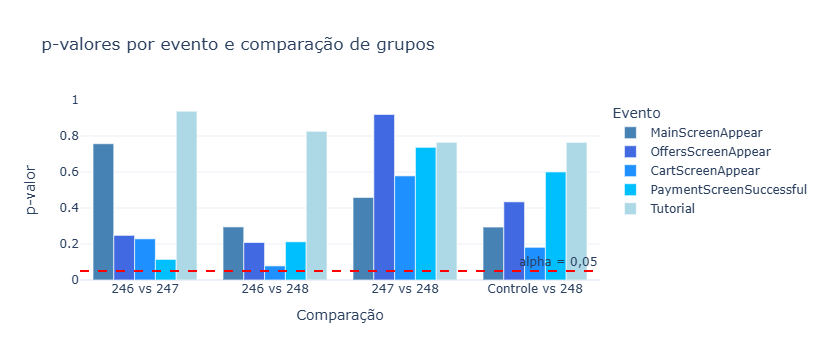

In [147]:
grupos_labels = ['246 vs 247', '246 vs 248', '247 vs 248', 'Controle vs 248']
cores_eventos = ['steelblue', 'royalblue', 'dodgerblue', 'deepskyblue', 'lightblue']

p_valores = {
    'MainScreenAppear':       [0.7571, 0.2950, 0.4587, 0.2942],
    'OffersScreenAppear':     [0.2481, 0.2084, 0.9198, 0.4343],
    'CartScreenAppear':       [0.2288, 0.0784, 0.5786, 0.1818],
    'PaymentScreenSuccessful':[0.1146, 0.2123, 0.7373, 0.6004],
    'Tutorial':               [0.9377, 0.8264, 0.7653, 0.7649],
}

fig = go.Figure()

for i, (evento, p_vals) in enumerate(p_valores.items()):
    fig.add_trace(go.Bar(
        name=evento,
        x=grupos_labels,
        y=p_vals,
        marker_color=cores_eventos[i],
        hovertemplate='Comparação: %{x}<br>p-valor: %{y:.4f}<extra>' + evento + '</extra>'
    ))

# linha do alpha = 0.05
fig.add_hline(
    y=0.05,
    line_dash='dash',
    line_color='red',
    annotation_text='alpha = 0,05',
    annotation_position='top right'
)

fig.update_layout(
    title='p-valores por evento e comparação de grupos',
    xaxis_title='Comparação',
    yaxis_title='p-valor',
    barmode='group',
    template='plotly_white',
    legend_title='Evento',
    yaxis=dict(range=[0, 1])
)

fig.show()

## Reflexão sobre o nível de significância

### Quantos testes realizamos?
- 5 eventos × 3 comparações (246 vs 247, 246 vs 248, 247 vs 248) = **15 testes**
- Mais 5 eventos no teste combinado (246+247 vs 248) = **20 testes no total**

### Problema da multiplicidade
Com alpha = 0,05, esperamos que **1 em cada 20 testes** seja falso positivo por acaso.
Como fizemos exatamente 20 testes, há risco real de um resultado falso.

### Correção de Bonferroni
Para corrigir isso, dividimos o alpha pelo número de testes:
- alpha corrigido = 0,05 / 20 = **0,0025**

### Impacto da correção
Mesmo com o alpha original de 0,05, nenhum teste foi significativo.
Com o alpha corrigido de 0,0025, a conclusão permanece a mesma:
**nenhuma diferença significativa entre os grupos**.
A conclusão do experimento é robusta e confiável. ✅

## Resultados do experimento A/A/B

### Teste A/B: Grupo 246 vs 248
| Evento | Grupo 246 | Grupo 248 | p-valor | Resultado |
|---|---|---|---|---|
| MainScreenAppear | 98,63% | 98,27% | 0,2950 | Sem diferença ✅ |
| OffersScreenAppear | 62,08% | 60,35% | 0,2084 | Sem diferença ✅ |
| CartScreenAppear | 50,97% | 48,48% | 0,0784 | Sem diferença ✅ |
| PaymentScreenSuccessful | 48,31% | 46,55% | 0,2123 | Sem diferença ✅ |
| Tutorial | 11,19% | 11,00% | 0,8264 | Sem diferença ✅ |

### Teste A/B: Grupo 247 vs 248
| Evento | Grupo 247 | Grupo 248 | p-valor | Resultado |
|---|---|---|---|---|
| MainScreenAppear | 98,53% | 98,27% | 0,4587 | Sem diferença ✅ |
| OffersScreenAppear | 60,49% | 60,35% | 0,9198 | Sem diferença ✅ |
| CartScreenAppear | 49,26% | 48,48% | 0,5786 | Sem diferença ✅ |
| PaymentScreenSuccessful | 46,08% | 46,55% | 0,7373 | Sem diferença ✅ |
| Tutorial | 11,26% | 11,00% | 0,7653 | Sem diferença ✅ |

### Teste A/B: Controle combinado (246+247) vs 248
| Evento | Controle | Grupo 248 | p-valor | Resultado |
|---|---|---|---|---|
| MainScreenAppear | 98,58% | 98,27% | 0,2942 | Sem diferença ✅ |
| OffersScreenAppear | 61,28% | 60,35% | 0,4343 | Sem diferença ✅ |
| CartScreenAppear | 50,11% | 48,48% | 0,1818 | Sem diferença ✅ |
| PaymentScreenSuccessful | 47,19% | 46,55% | 0,6004 | Sem diferença ✅ |
| Tutorial | 11,23% | 11,00% | 0,7649 | Sem diferença ✅ |

### Conclusão geral do experimento

- **Nenhum evento** apresentou diferença estatisticamente significativa
entre o grupo de teste e os grupos de controle
- A nova fonte **não prejudicou nem melhorou** o comportamento dos usuários
- O p-valor mais próximo do limite foi CartScreenAppear (0,0784 no teste 246 vs 248),
mas ainda acima do alpha de 0,05 — não é significativo

### Recomendação
A mudança de fonte pode ser implementada com segurança.
Os dados não mostram nenhum impacto negativo no comportamento dos usuários,
e o medo dos gerentes de que o novo design fosse intimidador **não foi confirmado**.